In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#define constants (cgs)
G = 6.67259e-8 #gravitational constant (dyne cm2/g2)
c = 29979245800 #speed of light (cm/s)
msun = 1.989e+33 #mass of the Sun (grams)
eV2erg = 1.60218e-12

def rg(M_BH):
    '''gravitational radius (in cm) as function of SMBH mass (in units of msun)'''
    return G*msun*M_BH/(c**2)

In [3]:
E_pho = np.load('E_pho.npy')
E_nu = np.load('E_nu.npy')
E_had = np.load('E_had.npy')

target_SED = np.load('target_1068.npy') #Marconi SED for L_X (2-10 keV) = 3e43 erg/s (Padovani et al., Nature Astronomy (2024))

In [4]:
#energy density of particles in the corona at steady state
photons = np.load('gamma_1068.npy')
neutrinos = np.load('neutrinos_1068.npy') #all-flavor
protons = np.load('protons_1068.npy')

"dimensions: sigma_tur, eta, R, Energy. The F_p parameter is a rescaling. Here F_p = 1"

'dimensions: sigma_tur, eta, R, Energy. The F_p parameter is a rescaling. Here F_p = 1'

In [5]:
#parameter grid
M_BH = 0.67e7 #Padovani et al., Nature Astronomy (2024)

rmin = 10*rg(M_BH)
rmax = 1000*rg(M_BH)

rgrid=np.logspace(np.log10(rmin),np.log10(rmax),18)
sigmagrid=np.logspace(-2,0,18)
etagrid=np.logspace(-2,0,16)

In [13]:
#example: best-fit solution for NGC 1068
index = [-1, 13, 0]
sigma = sigmagrid[index[0]]
eta = etagrid[index[1]]
radius = rgrid[index[2]]
F_p = 0.5

volume = 4/3 * np.pi * radius**3
t_escape = radius/c

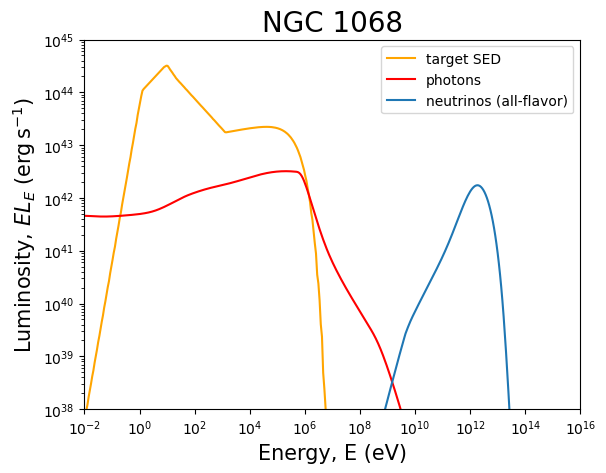

In [14]:
#plot luminosities for best-fit solution
plt.loglog(E_pho, target_SED, color = 'orange', label = 'target SED')
plt.loglog(E_pho, F_p * eV2erg*E_pho*photons[index[0], index[1], index[2], :] * volume / t_escape, color = 'red', label = 'photons')
plt.loglog(E_nu, F_p * eV2erg*E_nu*neutrinos[index[0], index[1], index[2], :] * volume / t_escape, label = 'neutrinos (all-flavor)')

plt.ylim(1e38, 1e45)
plt.xlim(1e-2, 1e16)
plt.xlabel('Energy, E (eV)', fontsize = 15)
plt.ylabel(r'Luminosity, $EL_E$ $(\mathrm{erg}\,\mathrm{s}^{-1})$', fontsize = 15)

plt.title('NGC 1068', fontsize = 20)
plt.legend()

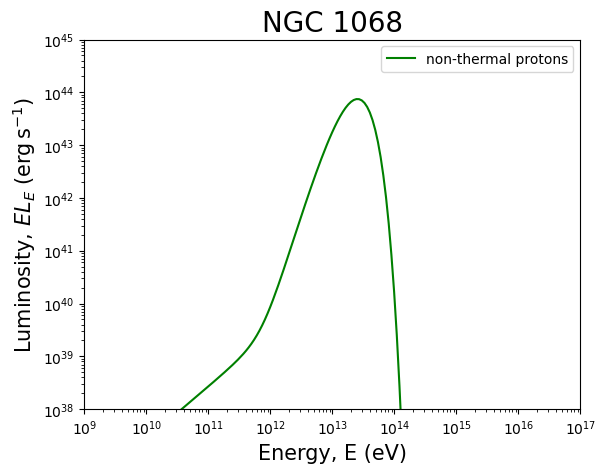

In [15]:
#plot spectrum of protons for best-fit solution
plt.loglog(E_had, F_p * eV2erg*E_had*protons[index[0], index[1], index[2], :] * volume / t_escape, color = 'green', label = 'non-thermal protons')

plt.ylim(1e38, 1e45)
plt.xlim(1e9, 1e17)
plt.xlabel('Energy, E (eV)', fontsize = 15)
plt.ylabel(r'Luminosity, $EL_E$ $(\mathrm{erg}\,\mathrm{s}^{-1})$', fontsize = 15)

plt.title('NGC 1068', fontsize = 20)
plt.legend()